In [7]:
pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [8]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import pandas as pd
import kagglehub
from ucimlrepo import fetch_ucirepo

# fetch dataset
statlog_heart = fetch_ucirepo(id=145)
UCI = kagglehub.dataset_download('redwankarimsony/heart-disease-data')
Kaggle = kagglehub.dataset_download('johnsmith88/heart-disease-dataset')

df2 = pd.read_csv(Kaggle+"/heart.csv")
df = pd.read_csv(UCI+"/heart_disease_uci.csv")

df3_features = statlog_heart.data.features
df3_targets = statlog_heart.data.targets

# Combine features and targets into a single DataFrame
df3 = pd.concat([df3_features, df3_targets], axis=1)

print('Data source import complete.')


100%|██████████| 12.4k/12.4k [00:00<00:00, 20.0MB/s]

Extracting files...


100%|██████████| 6.18k/6.18k [00:00<00:00, 12.4MB/s]

Extracting files...
Data source import complete.


In [9]:
# Importing Libararies
# To Handle Data
import pandas as pd
import numpy as np
# To visualize the Data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# for Data Peprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer,KNNImputer
# Import Iterative Imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# Machine Learning
from sklearn.model_selection import train_test_split
# For Classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier,RandomForestRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
# metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
# ignore warnings
import warnings
warnings.filterwarnings("ignore")



In [10]:
# Lets print the First Five Rows of the Dataset
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [11]:
unique_values = df['restecg'].unique()
print(unique_values)

['lv hypertrophy' 'normal' 'st-t abnormality' nan]


In [12]:
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [15]:
df2['sex'] = df2['sex'].replace({1: 'Male', 0: 'Female'})
df2['cp'] = df2['cp'].replace({0: 'asymptomatic', 1: 'atypical angina', 2: 'non-anginal', 3: 'typical angina'})
df2['fbs'] = df2['fbs'].replace({0: 'false', 1: 'true'})
df2['restecg'] = df2['restecg'].replace({0: 'normal', 1: 'ST-T wave abnormality', 2: 'left ventricular hypertrophy'})
df2['exang'] = df2['exang'].replace({0: 'no', 1: 'yes'})
df2['slope'] = df2['slope'].replace({0: 'downsloping', 1: 'flat', 2: 'upsloping'})
df2['thal'] = df2['thal'].replace({1: 'fixed defect', 2: 'normal', 3: 'reversable defect'})
df2['target'] = df2['target'].replace(1,2)
df2['sex'] = df2['sex'].astype(str)
df2['cp'] = df2['cp'].astype(str)
df2['trestbps'] = df2['trestbps'].astype(float)
df2['chol'] = df2['chol'].astype(float)
df2['fbs'] = df2['fbs'].astype(str)
df2['restecg']= df2['restecg'].astype(str)
df2['thalach'] = df2['thalach'].astype(float)
df2['exang'] = df2['exang'].astype(str)
df2['oldpeak'] = df2['oldpeak'].astype(float)
df2['slope'] = df2['slope'].astype(str)
df2['ca'] = df2['ca'].astype(float)
df2['thal'] = df2['thal'].astype(str)

In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   object 
 2   cp        1025 non-null   object 
 3   trestbps  1025 non-null   float64
 4   chol      1025 non-null   float64
 5   fbs       1025 non-null   object 
 6   restecg   1025 non-null   object 
 7   thalach   1025 non-null   float64
 8   exang     1025 non-null   object 
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   object 
 11  ca        1025 non-null   float64
 12  thal      1025 non-null   object 
 13  target    1025 non-null   int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 112.2+ KB


In [17]:
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,Male,asymptomatic,125.0,212.0,false,ST-T wave abnormality,168.0,no,1.0,upsloping,2.0,reversable defect,0
1,53,Male,asymptomatic,140.0,203.0,true,normal,155.0,yes,3.1,downsloping,0.0,reversable defect,0
2,70,Male,asymptomatic,145.0,174.0,false,ST-T wave abnormality,125.0,yes,2.6,downsloping,0.0,reversable defect,0
3,61,Male,asymptomatic,148.0,203.0,false,ST-T wave abnormality,161.0,no,0.0,upsloping,1.0,reversable defect,0
4,62,Female,asymptomatic,138.0,294.0,true,ST-T wave abnormality,106.0,no,1.9,flat,3.0,normal,0


In [18]:
df = df.drop('id', axis=1)
df = df.drop('dataset', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalch    865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    object 
 11  ca        309 non-null    float64
 12  thal      434 non-null    object 
 13  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


In [19]:
#combining both datasets

#df2['target'] = df2['target'].replace(1, 2)
df2 = df2.rename(columns={'target': 'num'})
df2 = df2.rename(columns={'thalach': 'thalch'})

df = pd.concat([df, df2], axis=0)
df['trestbps'] = pd.to_numeric(df['trestbps'], errors='coerce')

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [20]:
df.shape

(1945, 14)

In [21]:
# Lets Explore the age column
df['age'].min(), df['age'].max()

(28, 77)

<Axes: xlabel='num', ylabel='Count'>

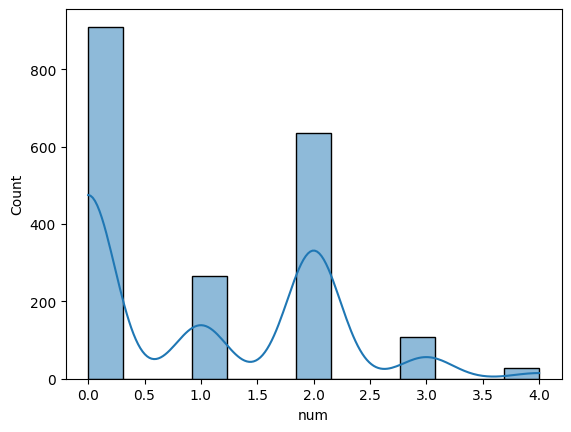

In [22]:
sns.histplot(df['num'], kde=True)

<Axes: xlabel='age', ylabel='Count'>

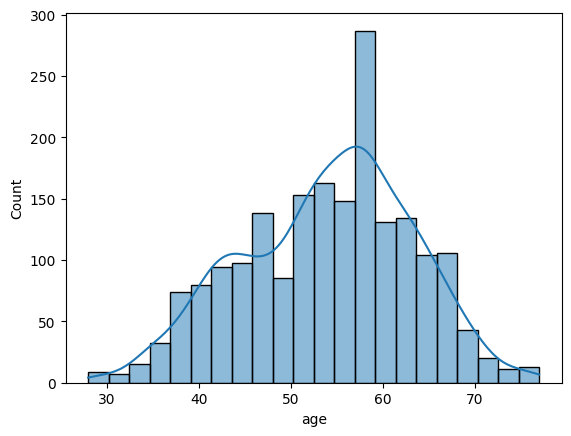

In [23]:
# plot the Histplot of the age column using Seaborn Libarary
sns.histplot(df['age'], kde=True)

Mean of age column:  53.9974293059126
Median of age column:  55.0
Mode of age column:  58


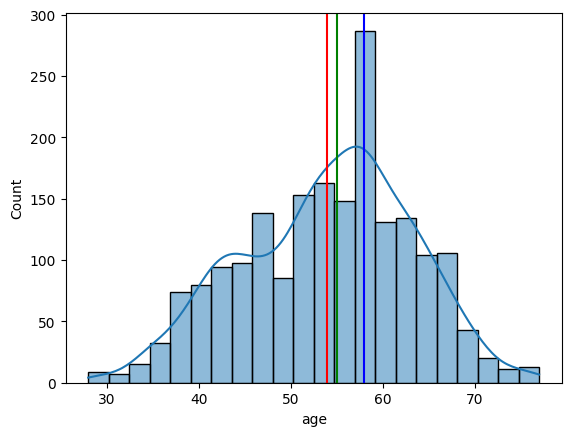

In [24]:
# plot the Histplot of the age column using Seaborn Libarary
sns.histplot(df['age'], kde=True)
# plot the mean,median,mode of the age column using matplotlib
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
plt.axvline(df['age'].mode()[0], color='blue')
# Print the mean,median,mode of the age column
print("Mean of age column: ", df['age'].mean())
print("Median of age column: ", df['age'].median())
print("Mode of age column: ", df['age'].mode()[0])

In [25]:
# Lets plot the Histogram plot by coloring on the basis of sex using plotly
fig=px.histogram(data_frame=df, x='age', color='sex')
fig.show()

In [26]:
# Applying the groupby function to check the males and Females get the HeartDisease at whch age
df.groupby('sex')['age'].value_counts()

sex     age
Female  62     34
        54     30
        58     28
        51     23
        63     23
               ..
Male    71      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [27]:
df['sex'].value_counts()

,count
sex,
Male,1439
Female,506


In [28]:
# Calculate the percentage of male and female by first calculating the male and female count
male_count=726
Female_count=194
total_count=male_count+Female_count
# Calculate the percentage of male and Female
percentage_male = (male_count / total_count) * 100
percentage_Female = (Female_count / total_count) * 100
# Display the Male and Female percentages present in the Dataset
print(f"The percentage of male is: {percentage_male:.2f}%")
print(f"The percentage of Female is: {percentage_Female:.2f}%")
# Calculate the Difference
Difference_percentage=(male_count-Female_count)/(Female_count)*100
# Print the Difference in percentage of Male and Female
print(f"percentage_male is {Difference_percentage: .2f}% more than female_percentage")

The percentage of male is: 78.91%
The percentage of Female is: 21.09%
percentage_male is  274.23% more than female_percentage


In [29]:
df['cp'].value_counts()

,count
cp,
asymptomatic,993
non-anginal,488
atypical angina,341
typical angina,123


In [30]:
# Lets Apply the groupby function on cp and age column
df.groupby('cp')['sex'].value_counts()

cp               sex   
asymptomatic     Male      790
                 Female    203
atypical angina  Male      223
                 Female    118
non-anginal      Male      326
                 Female    162
typical angina   Male      100
                 Female     23
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

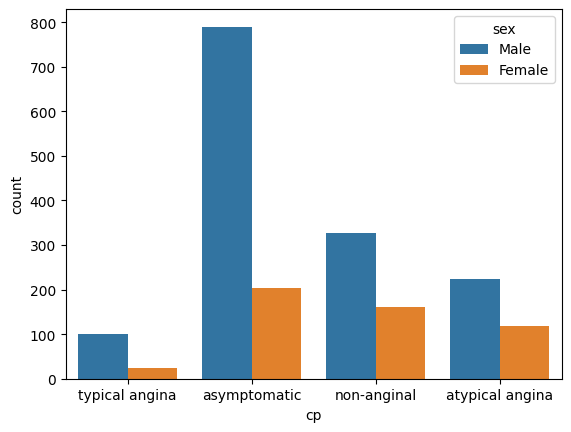

In [31]:
# plot the count plot of the cp column on the basis of age using the seaborn
sns.countplot(df, x='cp', hue='sex')

In [32]:
# plot the Histogrram of cp column based on sex
fig=px.histogram(data_frame=df, x='age', color='cp')
fig.show()

In [33]:
df['trestbps'].describe()

,trestbps
count,1886.000000
mean,131.849417
std,18.237299
min,0.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


In [34]:
df['trestbps'].unique()

array([145., 160., 120., 130., 140., 172., 150., 110., 132., 117., 135.,
       112., 105., 124., 125., 142., 128., 170., 155., 104., 180., 138.,
       108., 134., 122., 115., 118., 100., 200.,  94., 165., 102., 152.,
       101., 126., 174., 148., 178., 158., 192., 129., 144., 123., 136.,
       146., 106., 156., 154., 114., 164.,  98., 190.,  nan, 113.,  92.,
        95.,  80., 185., 116.,   0.,  96., 127.])

In [35]:
df.isnull().sum().sort_values(ascending=False)
missing_data_cols=df.isnull().sum()[df.isnull().sum()>0].index.tolist()
missing_data_cols

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [36]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [37]:
cat_cols=['sex','cp','fbs','restecg','exang','slope','thal']
bool_cols=['fbs','exang']
numeric_cols=['age','trestbps','chol','thalch','oldpeak','ca','num']

df[cat_cols] = df[cat_cols].astype(str)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# print the cat_cols,bool_cols,numeric_cols
print('Categorical Variables:',cat_cols)
print('Binary Variables:', bool_cols)
print('Numeric Variables:', numeric_cols)

Categorical Variables: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Binary Variables: ['fbs', 'exang']
Numeric Variables: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [38]:
dupes = df.columns[df.columns.duplicated()]
print("Duplicate column names:", dupes.tolist())

Duplicate column names: []


In [39]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [40]:
def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", mean_squared_error(y_test, y_pred), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    # Reset index before concatenation to avoid duplicate index values
    df_not_null = df_not_null.reset_index(drop=True)
    df_null = df_null.reset_index(drop=True)

    df_combined = pd.concat([df_not_null, df_null])

    # Reset index of the combined dataframe to avoid potential issues
    df_combined = df_combined.reset_index(drop=True)

    return df_combined[passed_col]

In [41]:
for cols in missing_data_cols:
    print('missing_values', cols, ':', str(round(df.isnull().sum()/len(df)*100, 2))+'%')
    if cols in cat_cols:
        df[cols] = impute_categorical_missing_data(cols)
    elif cols in numeric_cols:
        df[cols] = impute_continuous_missing_data(cols)
    else:
        pass

missing_values trestbps : age          0.00
sex          0.00
cp           0.00
trestbps     3.03
chol         1.54
fbs          0.00
restecg      0.00
thalch       2.83
exang        0.00
oldpeak      3.19
slope        0.00
ca          31.41
thal         0.00
num          0.00
dtype: float64%
MAE = 5.919550264550265 

RMSE = 97.01419444444444 

R2 = 0.6954300820141682 

missing_values chol : age          0.00
sex          0.00
cp           0.00
trestbps     0.00
chol         1.54
fbs          0.00
restecg      0.00
thalch       2.83
exang        0.00
oldpeak      3.19
slope        0.00
ca          31.41
thal         0.00
num          0.00
dtype: float64%
MAE = 33.974673629242815 

RMSE = 4113.508286684073 

R2 = 0.4343905254384711 

missing_values fbs : age          0.00
sex          0.00
cp           0.00
trestbps     0.00
chol         0.00
fbs          0.00
restecg      0.00
thalch       2.83
exang        0.00
oldpeak      3.19
slope        0.00
ca          31.41
thal         0.00
nu

In [42]:
df.groupby('trestbps')['sex'].value_counts()

trestbps  sex   
0.0       Male      2
80.0      Male      2
92.0      Male      2
94.0      Female    2
          Male      2
                   ..
190.0     Male      3
          Female    1
192.0     Male      3
200.0     Male      5
          Female    3
Name: count, Length: 106, dtype: int64

In [43]:
# Lets do the Feature Engineering of the trestbps column and create new column on the basis of very_low, low, normal, high, very_high
bins=[0,60,80,130, 135, 140]
labels=['very_low', 'low','Normal', 'high', 'very_high']
df['trestbps_bins']=pd.cut(df['trestbps'], bins=bins, labels=labels)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,trestbps_bins
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,NaN
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,NaN
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Normal
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal


In [44]:
# Lets impute the missing values of trestos with mode
df['trestbps_bins'].fillna(df['trestbps_bins'].mode()[0], inplace=True)
df['trestbps_bins'].isnull().sum()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,trestbps_bins
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,Normal
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,Normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Normal
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal


<Axes: xlabel='trestbps', ylabel='Count'>

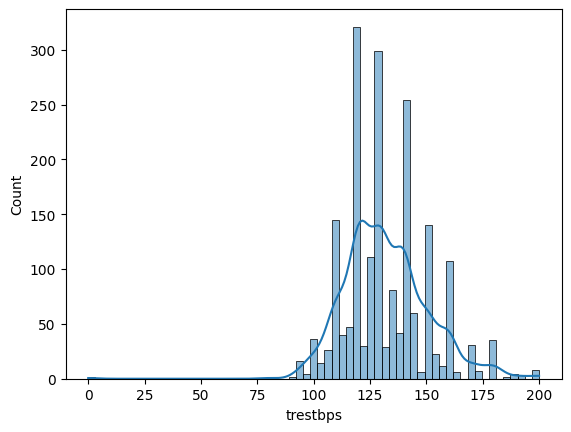

In [45]:
sns.histplot(df, x='trestbps', kde=True)

In [46]:
fig=px.histogram(df, x='trestbps', color='sex')
fig.show()

In [47]:
df['chol'].describe()

,chol
count,1945.000000
mean,202.687918
std,107.593192
min,0.000000
25%,180.000000
50%,224.000000
75%,269.000000
max,603.000000


In [48]:
df.groupby('chol')['sex'].value_counts()

chol   sex   
0.0    Male      275
       Female     69
85.0   Male        2
100.0  Male        3
       Female      1
                ... 
529.0  Male        1
564.0  Female      1
       Male        1
603.0  Female      1
       Male        1
Name: count, Length: 386, dtype: int64

In [49]:
fig=px.histogram(data_frame=df, x='chol', color='sex')
fig.show()

In [50]:
df['fbs'].value_counts()

,count
fbs,
false,872
False,692
true,153
True,138
nan,90


In [51]:
df.groupby('fbs')['sex'].value_counts()

fbs    sex   
False  Male      528
       Female    164
True   Male      119
       Female     19
false  Male      602
       Female    270
nan    Male       79
       Female     11
true   Male      111
       Female     42
Name: count, dtype: int64

In [52]:
df.groupby('fbs')['age'].value_counts()

fbs    age
False  54     42
       55     32
       58     31
       52     27
       59     26
              ..
true   46      3
       51      3
       61      3
       67      3
       69      3
Name: count, Length: 180, dtype: int64

In [53]:
fig=px.bar(data_frame=df, x='fbs', y='age', color='sex')
fig.show()

In [54]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,trestbps_bins
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,Normal
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,Normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Normal
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal


In [55]:
df['restecg'].value_counts()


,count
restecg,
normal,1048
ST-T wave abnormality,513
lv hypertrophy,188
st-t abnormality,179
left ventricular hypertrophy,15
nan,2


In [56]:
df['restecg']=df['restecg'].apply(lambda x:x.replace(' ', '-')if ' ' in str(x) else x)

In [57]:
df.groupby('restecg')['sex'].value_counts()

restecg                       sex   
ST-T-wave-abnormality         Male      356
                              Female    157
left-ventricular-hypertrophy  Female     11
                              Male        4
lv-hypertrophy                Male      141
                              Female     47
nan                           Male        2
normal                        Male      785
                              Female    263
st-t-abnormality              Male      151
                              Female     28
Name: count, dtype: int64

In [58]:
fig=px.histogram(data_frame=df, x='age', color='restecg')
fig.show()

In [59]:
df['thalch'].describe()

,thalch
count,1945.000000
mean,138.908483
std,25.804601
min,60.000000
25%,120.000000
50%,140.000000
75%,159.000000
max,202.000000


In [60]:
fig=px.histogram(data_frame=df, x='thalch', color='sex')
fig.show()

In [61]:
# Lets explore the exang column
df['oldpeak'].describe()

,oldpeak
count,1945.000000
mean,0.914961
std,1.131415
min,-2.600000
25%,0.000000
50%,0.500000
75%,1.500000
max,6.200000


<Axes: ylabel='oldpeak'>

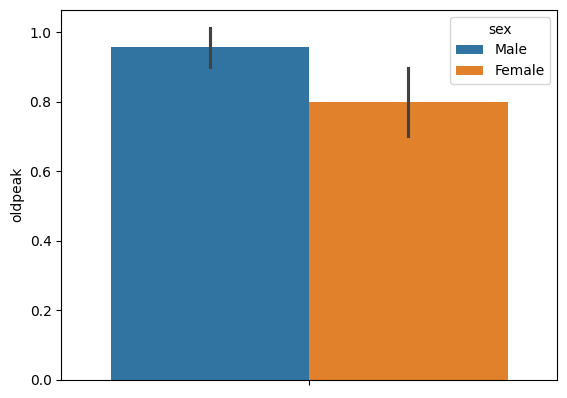

In [62]:
# plot the hist plot of exang column using seaborn
sns.barplot(df, y='oldpeak', hue='sex')

In [63]:
df['slope'].value_counts()

,count
slope,
flat,827
upsloping,672
nan,309
downsloping,137


In [64]:
fig=px.histogram(data_frame=df, x='age', color='slope')
fig.show()

In [65]:
# Lets Explore the ca column
df['ca'].describe()

,ca
count,1945.000000
mean,0.736247
std,1.016250
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


In [66]:
# Lets explore the thal column
df['thal'].value_counts()

,count
thal,
normal,740
reversable defect,602
nan,486
fixed defect,110
0,7


In [67]:
df['thal']=df['thal'].apply(lambda x:x.replace(' ', '-')if ' ' in str(x) else x)

In [68]:
# calculatr the value counts of thal column by groupby with sex column
df.groupby('thal')['sex'].value_counts()

thal               sex   
0                  Male        4
                   Female      3
fixed-defect       Male      102
                   Female      8
nan                Male      403
                   Female     83
normal             Male      402
                   Female    338
reversable-defect  Male      528
                   Female     74
Name: count, dtype: int64

In [69]:
fig=px.histogram(data_frame=df, x='sex', color='thal')
fig.show()

In [70]:
bins=[0,1,2,3,4]
labels=['No-Heart-Disease', 'Mild-Heart-Disease', 'Moderate-Heart-Disease', 'Severe-Heart-Disease']
df['num_bins']=pd.cut(df['num'], bins=bins, labels=labels)


In [71]:
df['num_bins'].fillna(df['num_bins'].mode()[0], inplace=True)


In [72]:
df['num'].value_counts()

,count
num,
0,910
2,635
1,265
3,107
4,28


In [73]:
df.groupby('num')['sex'].value_counts()

num  sex   
0    Male      680
     Female    230
1    Male      235
     Female     30
2    Male      399
     Female    236
3    Male       99
     Female      8
4    Male       26
     Female      2
Name: count, dtype: int64

In [74]:
fig=px.box(data_frame=df, y='age')
fig.show()
fig=px.box(data_frame=df, y='trestbps')
fig.show()
fig=px.box(data_frame=df, y='chol')
fig.show()
fig=px.box(data_frame=df, y='thalch')
fig.show()
fig=px.box(data_frame=df, y='oldpeak')
fig.show()


In [75]:
# check the row where trestbps is 0
df[df['trestbps']==0]
# Remove the row where trestbps is not equal to zero
df=df[df['trestbps']!=0]


In [76]:

# lets encode the sex column using label encoder
le_sex=LabelEncoder()
df['sex']=le_sex.fit_transform(df[['sex']])
# lets encode the cp column using label encoder
le_cp=LabelEncoder()
df['cp']=le_cp.fit_transform(df[['cp']])
# lets encode the fbs column using label encoder
le_fbs=LabelEncoder()
df['fbs']=le_fbs.fit_transform(df[['fbs']])
# lets encode the trestecg column using label encoder
le_restecg=LabelEncoder()
df['restecg']=le_restecg.fit_transform(df[['restecg']])
# lets encode the exang column using label encoder
le_exang=LabelEncoder()
df['exang']=le_exang.fit_transform(df[['exang']])
# lets encode the slope column using label encoder
le_slope=LabelEncoder()
df['slope']=le_slope.fit_transform(df[['slope']])
# lets encode the thal column using label encoder
le_thal=LabelEncoder()
df['thal']=le_thal.fit_transform(df[['thal']])
# lets encode the trest_bins column using label encoder
le_trestbps_bins=LabelEncoder()
df['trestbps_bins']=le_trestbps_bins.fit_transform(df[['trestbps_bins']])
le_num_bins=LabelEncoder()
df['num_bins']=le_trestbps_bins.fit_transform(df[['num_bins']])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,trestbps_bins,num_bins
0,63,1,3,145.0,233.0,1,2,150.0,0,2.3,0,0.0,1,0,0,0
1,67,1,0,160.0,286.0,0,2,108.0,1,1.5,1,3.0,3,2,0,0
2,67,1,0,120.0,229.0,0,2,129.0,1,2.6,1,2.0,4,1,0,2
3,37,1,2,130.0,250.0,0,4,187.0,0,3.5,0,0.0,3,0,0,0
4,41,0,1,130.0,204.0,0,2,172.0,0,1.4,3,0.0,3,0,0,0


In [77]:
cat_cols=['sex','cp','fbs','restecg','exang','slope','thal','trestbps_bins','num_bins']
bool_cols=['fbs','exang']
numeric_cols=['age','trestbps','chol','thalch','oldpeak','ca']


In [78]:
scalar=StandardScaler()
df[numeric_cols]=scalar.fit_transform(df[numeric_cols])

In [79]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
qt_normal=QuantileTransformer(output_distribution='normal', random_state=42)
df[numeric_cols]=qt_normal.fit_transform(df[numeric_cols])

In [80]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,trestbps_bins,num_bins
0,0.961429,1,3,0.798769,0.137177,1,2,0.345485,0,1.186981,0,-5.199338,1,0,0,0
1,1.497997,1,0,1.428482,0.947580,0,2,-1.174387,1,0.604448,1,1.659093,3,2,0,0
2,1.497997,1,0,-0.642543,0.072829,0,2,-0.376283,1,1.334066,1,1.048748,4,1,0,2
3,-1.792374,1,2,-0.005018,0.395204,0,4,2.225823,0,1.880352,0,-5.199338,3,0,0,0
4,-1.298271,0,1,-0.005018,-0.374936,0,2,1.283836,0,0.503497,3,-5.199338,3,0,0,0


In [81]:
%%time
# importing libarariesfor classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
# import pipeline
from sklearn.pipeline import Pipeline
import random



# Remove Warnings
import warnings
warnings.filterwarnings('ignore')
# Disable LightGBM warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="No further splits with positive gain")

# Split the Data into X and y
X=df.drop('num', axis=1)
y=df['num']
random_state=42

# Split the Data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)
# call the models
models = {
    'Logistic Regression': (LogisticRegression(random_state=42), {}),
    'KNN': (KNeighborsClassifier(), {'model__n_neighbors': [10, 30]}),
    'SVC': (SVC(random_state=42), {'model__gamma': ['scale', 'auto']}),
    'DecisionTreeClassifier': (DecisionTreeClassifier(random_state=42), {'model__max_depth': [5, 10, 15]}),
    'RandomForestClassifier': (RandomForestClassifier(random_state=42), {'model__n_estimators': [100, 200, 300], 'model__max_depth': [5, 10, 15]}),
    'GradientBoostingClassifier': (GradientBoostingClassifier(random_state=42), {'model__learning_rate': [0.1, 0.01, 0.001]}),
    'AdaBoostClassifier': (AdaBoostClassifier(random_state=42), {'model__n_estimators': [50, 100, 200]}),
    'XGBClassifier': (XGBClassifier(random_state=42), {'model__max_depth': [3, 4, 5]}),
    'Naive Bayes': (GaussianNB(), {})
}
best_model=None
best_accuracy=0
for name,(models,params) in models.items():
    pipeline=Pipeline(steps=[
        ('model',models)
])
    # Apply the cross validation score
    scores=cross_val_score(pipeline, X_train, y_train,cv=5, verbose=0)
    # mean_accuracy
    mean_accuracy=scores.mean()
    # predict the pipeline
    pipeline.fit(X_train,y_train)
    # Train the pipeline
    y_pred=pipeline.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred,average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')

    if hasattr(pipeline, 'predict_proba'):
        y_pred_proba = pipeline.predict_proba(X_test)
        try:
             # Specify multi_class='ovr' as per the previous calculation attempt
             roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
        except ValueError as e:
             print(f"Could not calculate ROC AUC for {name}: {e}")
             roc_auc = None # Assign None if ROC AUC calculation fails
    else:
        print(f"Model {name} does not support predict_proba. Skipping ROC AUC calculation.")
        roc_auc = None

    # print the evaluation metrics
    print('Model', name)
    print('Cross_validation accuracy', mean_accuracy)
    print('accuracy', accuracy)
    print('f1_score', f1)
    if roc_auc is not None: # Only print if ROC AUC was calculated
        print('roc_auc', roc_auc)
    #print('recall', recall)
    #print('precision', precision)
    print('\n')


    # Evaluate the model
    if accuracy > best_accuracy:
       best_accuracy = accuracy
       best_model = pipeline
# print the best model
print("Best Model is:", best_model)
# Save the best model
# import pickle
# pickle.dump(best_model, open('./save the models/Heart_Disese_project_pkl','wb'))





Model Logistic Regression
Cross_validation accuracy 0.7728658852816098
accuracy 0.7892030848329049
f1_score 0.855313001854397
roc_auc 0.9404099547929009


Model KNN
Cross_validation accuracy 0.7207281402344156
accuracy 0.7403598971722365
f1_score 0.542776421573414
roc_auc 0.846496537871787


Model SVC does not support predict_proba. Skipping ROC AUC calculation.
Model SVC
Cross_validation accuracy 0.7825101130588112
accuracy 0.8457583547557841
f1_score 0.6970694517348763


Model DecisionTreeClassifier
Cross_validation accuracy 0.8738678560315319
accuracy 0.9254498714652957
f1_score 0.9612769405282775
roc_auc 0.9682461438471485


Model RandomForestClassifier
Cross_validation accuracy 0.8783777616429831
accuracy 0.8997429305912596
f1_score 0.7448935113275401
roc_auc 0.9898715714928137


Model GradientBoostingClassifier
Cross_validation accuracy 0.8796701586972306
accuracy 0.884318766066838
f1_score 0.9393039929286205
roc_auc 0.9837619696935367


Model AdaBoostClassifier
Cross_validation 

In [82]:

# split the data into X and y
X= df.drop('num', axis=1)
y = df['num']

# encode X data using separate label encoder for all categorical columns and save it for inverse transform
# Task: Separate Encoder for all categorical and object columns and inverse transform at the end.
Label_Encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = Label_Encoder.fit_transform(X[col])
    else:
        pass


# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# create a list of models to evaluate

models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('KNeighbors Classifier', KNeighborsClassifier()),
    ('Decision Tree Classifier', DecisionTreeClassifier(random_state=42)),
    ('Naive base Classifier', GaussianNB())


]

models = {
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('KNN', KNeighborsClassifier()),
    ('SVC', SVC(random_state=42)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=42)),
    ('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)),
    ('AdaBoostClassifier', AdaBoostClassifier(random_state=42)),
    ('XGBClassifier', XGBClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
}

best_model = None
best_accuracy = 0.0

#Iterate over the models and evaluate their performance
for name, model in models:
    #create a pipeline for each model
    pipeline = Pipeline([
        ('model', model)
    ])

    # perform cross validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)

    # Calculate mean accuracy
    mean_accuracy = scores.mean()

    #fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # make prediction on the test data
    y_pred = pipeline.predict(X_test)

    #Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    f1=f1_score(y_test,y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    if hasattr(pipeline, 'predict_proba'):
        y_pred_proba = pipeline.predict_proba(X_test)
        try:
             # Specify multi_class='ovr' as per the previous calculation attempt
             roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
        except ValueError as e:
             print(f"Could not calculate ROC AUC for {name}: {e}")
             roc_auc = None # Assign None if ROC AUC calculation fails
    else:
        print(f"Model {name} does not support predict_proba. Skipping ROC AUC calculation.")
        roc_auc = None


    #print the performance metrics
    print("Model", name)
    print("Cross Validatino accuracy: ", mean_accuracy)
    print("Test Accuracy: ", accuracy)
    print('f1_score', f1)
    if roc_auc is not None: # Only print if ROC AUC was calculated
        print('roc_auc', roc_auc)
    #print('recall', recall)
    #print('precision', precision)
    print('\n')
    print()

    #Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the best model
print("Best Model: ", best_model)


Model Naive Bayes
Cross Validatino accuracy:  0.7741147183902085
Test Accuracy:  0.8149100257069408
f1_score 0.9038360483447189
roc_auc 0.9556498988710395



Model KNN
Cross Validatino accuracy:  0.7329716834353281
Test Accuracy:  0.7583547557840618
f1_score 0.49577247676685443
roc_auc 0.812179498436767



Model SVC does not support predict_proba. Skipping ROC AUC calculation.
Model SVC
Cross Validatino accuracy:  0.7998755315838606
Test Accuracy:  0.8431876606683805
f1_score 0.6714879535119554



Model GradientBoostingClassifier
Cross Validatino accuracy:  0.8790270718805102
Test Accuracy:  0.910025706940874
f1_score 0.9516973789889255
roc_auc 0.9877422043073247



Model RandomForestClassifier
Cross Validatino accuracy:  0.8777429727206721
Test Accuracy:  0.9254498714652957
f1_score 0.8735394710691153
roc_auc 0.9903051513477006



Model Logistic Regression
Cross Validatino accuracy:  0.7631988382947826
Test Accuracy:  0.7917737789203085
f1_score 0.781094224924012
roc_auc 0.94738225236